✅ Cell 1 — Imports

In [1]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — Imports
# ═══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    f1_score,
    average_precision_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew

from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek, SMOTEENN

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("✅ Imports done")

✅ Imports done


In [2]:
# ═══════════════════════════════════════════════════════════
# CELL 2 — Load Data
# ═══════════════════════════════════════════════════════════
train_df = pd.read_csv("../data/raw/train.csv")
val_df   = pd.read_csv("../data/raw/val.csv")

# Separate features from target
X_train_raw = train_df.drop(columns=["Class"])
y_train     = train_df["Class"].values

X_val_raw   = val_df.drop(columns=["Class"])
y_val       = val_df["Class"].values

print(f"  Train : {X_train_raw.shape} | Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"  Val   : {X_val_raw.shape} ✅ loaded")


  Train : (170884, 30) | Fraud: 305 (0.178%)
  Val   : (56960, 30) ✅ loaded


In [3]:
# ═══════════════════════════════════════════════════════════
# CELL 3 — Feature Engineering (same as notebook 2)
# ═══════════════════════════════════════════════════════════
def apply_feature_engineering(X: pd.DataFrame, time_max: float = None):
    """
    Apply feature engineering steps.
    
    time_max : must be passed from Train — never computed from Val/Test
               to avoid data leakage
    """
    X = X.copy()
    
    X["log_amount"] = np.log1p(X["Amount"])
    
    if time_max is None:
        time_max = X["Time"].max()
    
    X["time_sin"] = np.sin(2 * np.pi * X["Time"] / time_max)
    X["time_cos"] = np.cos(2 * np.pi * X["Time"] / time_max)
    
    X.drop(columns=["Amount", "Time"], inplace=True)
    
    return X

# Compute time_max from Train ONLY
time_max = X_train_raw["Time"].max()

X_train_eng = apply_feature_engineering(X_train_raw, time_max=time_max)
X_val_eng   = apply_feature_engineering(X_val_raw,   time_max=time_max)

print(f"  X_train_eng : {X_train_eng.shape}")
assert X_val_eng.shape[1] == X_train_eng.shape[1], "❌ Feature mismatch!"
print("  ✅ Val features match Train features")
print(f"  ✅ time_max from Train only: {time_max}")

  X_train_eng : (170884, 31)
  ✅ Val features match Train features
  ✅ time_max from Train only: 172792.0


In [4]:
# ═══════════════════════════════════════════════════════════
# CELL 4 — Scaling 
# ═══════════════════════════════════════════════════════════
scaler = StandardScaler()

# fit_transform على Train
X_train_scaled = scaler.fit_transform(X_train_eng)

# transform فقط على Val — مش fit
X_val_scaled = scaler.transform(X_val_eng)

feature_names = list(X_train_eng.columns)

print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  ✅ Scaler fitted on Train only")

# Verify
assert X_train_scaled.shape[1] == X_val_scaled.shape[1], "❌ Shape mismatch!"
print(f"  ✅ Train and Val have same number of features")


  X_train_scaled : (170884, 31)
  ✅ Scaler fitted on Train only
  ✅ Train and Val have same number of features


In [5]:
# ═══════════════════════════════════════════════════════════
# CELL 5 — find_best_threshold
# ═══════════════════════════════════════════════════════════
def find_best_threshold(y_true, probs):
    """
    Find the threshold that maximizes F1-score.
    
    Uses Precision-Recall Curve — more reliable than
    looping over a fixed grid of values.
    
    Why F1?
    → In fraud detection we care about both:
      - Precision: لما نقول fraud — هل هو فعلاً fraud؟
      - Recall: من كل الـ fraud الحقيقي — كام اكتشفنا؟
    → F1 = التوازن بين الاتنين
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)

    f1_scores = np.where(
        (precisions + recalls) == 0,
        0,
        2 * precisions * recalls / (precisions + recalls)
    )

    # thresholds أقصر بـ 1 من precisions و recalls
    best_idx       = np.argmax(f1_scores[:-1])
    best_threshold = float(thresholds[best_idx])
    best_f1        = float(f1_scores[best_idx])

    return best_threshold, best_f1

In [6]:
# ═══════════════════════════════════════════════════════════
# CELL 6 — evaluate_model
# ═══════════════════════════════════════════════════════════
def evaluate_model(y_true, probs, threshold, label=""):
    """
    Compute F1, PR-AUC, ROC-AUC and print full report.
    Primary metric = F1 Score
    """
    preds   = (probs >= threshold).astype(int)

    f1      = f1_score(y_true, preds,  zero_division=0)
    pr_auc  = average_precision_score(y_true, probs)
    roc_auc = roc_auc_score(y_true, probs)

    if label:
        print(f"\n{'─'*50}")
        print(f"  {label}")
        print(f"  Threshold  : {threshold:.4f}")
        print(f"  F1-Score   : {f1:.4f}   ← Primary Metric")
        print(f"  PR-AUC     : {pr_auc:.4f}")
        print(f"  ROC-AUC    : {roc_auc:.4f}")
        print(f"\n  Confusion Matrix:")
        cm = confusion_matrix(y_true, preds)
        print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
        print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")
        print(f"\n{classification_report(y_true, preds, zero_division=0)}")

    return f1, pr_auc, roc_auc

In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 7 — get_scale_pos_weight
# ═══════════════════════════════════════════════════════════
def get_scale_pos_weight(y):
    """
    Compute scale_pos_weight for XGBoost.
    Formula: count(negatives) / count(positives)
    
    In our case: 170,579 / 305 = 559.28
    """
    counter = Counter(y)
    return counter[0] / counter[1]

# Test the functions
print("  Testing helper functions...")

# Test find_best_threshold
dummy_y     = np.array([0, 0, 0, 1, 1])
dummy_probs = np.array([0.1, 0.2, 0.4, 0.7, 0.9])
thresh, f1  = find_best_threshold(dummy_y, dummy_probs)
print(f"  ✅ find_best_threshold works | threshold={thresh:.2f} | f1={f1:.2f}")

# Test evaluate_model
f1, pr_auc, roc_auc = evaluate_model(dummy_y, dummy_probs, thresh)
print(f"  ✅ evaluate_model works      | f1={f1:.2f}")

# Test get_scale_pos_weight
spw = get_scale_pos_weight(y_train)
print(f"  ✅ scale_pos_weight          | {spw:.2f}")


  Testing helper functions...
  ✅ find_best_threshold works | threshold=0.70 | f1=1.00
  ✅ evaluate_model works      | f1=1.00
  ✅ scale_pos_weight          | 559.28


In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 8 — Define Samplers
# ═══════════════════════════════════════════════════════════
RANDOM_STATE = 42

samplers = {
    "none":          None,
    "random_over":   RandomOverSampler(random_state=RANDOM_STATE),
    "random_under":  RandomUnderSampler(random_state=RANDOM_STATE),
    "smote":         SMOTE(k_neighbors=5, random_state=RANDOM_STATE),
    "adasyn":        ADASYN(n_neighbors=5, random_state=RANDOM_STATE),
    "smote_tomek":   SMOTETomek(random_state=RANDOM_STATE, n_jobs=-1),
    "smote_enn":     SMOTEENN(random_state=RANDOM_STATE, n_jobs=-1),
}

print("  Sampling strategies defined:")
for name in samplers:
    print(f"    - {name}")

  Sampling strategies defined:
    - none
    - random_over
    - random_under
    - smote
    - adasyn
    - smote_tomek
    - smote_enn


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 9 — CV Strategy + Param Grids
# ═══════════════════════════════════════════════════════════

# StratifiedKFold — يحافظ على نسبة الـ fraud في كل fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Logistic Regression
log_param_grid = {
    "C": [0.1, 1, 10],
    "penalty": ["l1", "l2"],
}

# Random Forest
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5],
}

# XGBoost
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}

# Neural Network
nn_param_grid = {
    "hidden_layer_sizes": [(64, 32), (128, 64)],
    "alpha": [0.0001, 0.001],
}

print("  CV Strategy : StratifiedKFold (5 folds)")
print("  Scoring     : F1  ← Primary Metric")
print("\n  Param grids defined:")
print(f"    Logistic RF : {2*3}  combinations")
print(f"    Random Forest : {2*2*2} combinations")
print(f"    XGBoost       : {2*2*2} combinations")
print(f"    Neural Network: {2*2}  combinations")

  CV Strategy : StratifiedKFold (5 folds)
  Scoring     : F1  ← Primary Metric

  Param grids defined:
    Logistic RF : 6  combinations
    Random Forest : 8 combinations
    XGBoost       : 8 combinations
    Neural Network: 4  combinations

  Estimated time : 20-30 minutes for full loop


In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 10 — Initialize Results Storage
# ═══════════════════════════════════════════════════════════
results        = []
trained_models = {}

print("  ✅ Results storage initialized")

  ✅ Results storage initialized


In [11]:
# ═══════════════════════════════════════════════════════════
# CELL 11 — Main Pipeline Loop
# ═══════════════════════════════════════════════════════════
for sampler_name, sampler in samplers.items():

    print(f"\n{'='*55}")
    print(f"  SAMPLER: {sampler_name.upper()}")
    print(f"{'='*55}")

    # ──────────────────────────────────────────────────────
    # STEP 1: Apply Sampling on Train ONLY
    # ──────────────────────────────────────────────────────
    X_res, y_res = X_train_scaled, y_train
    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)
    
    print(f"  Class distribution: {Counter(y_res)}")

    # ──────────────────────────────────────────────────────
    # STEP 2: Feature Selection (fit on resampled Train only)
    # ──────────────────────────────────────────────────────
    fs_rf = RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    fs_rf.fit(X_res, y_res)

    selector  = SelectFromModel(fs_rf, threshold="median", prefit=True)
    X_res_sel = selector.transform(X_res)
    X_val_sel = selector.transform(X_val_scaled)

    print(f"  Features: {X_res.shape[1]} → {X_res_sel.shape[1]} selected")

    selected_features = [feature_names[i]
                         for i in selector.get_support(indices=True)]

    # scale_pos_weight من الـ resampled labels
    spw = get_scale_pos_weight(y_res)

    # ──────────────────────────────────────────────────────
    # STEP 3: Train Models
    # ──────────────────────────────────────────────────────

    sampler_models = {}

    # ── Logistic Regression ───────────────────────────────
    print("\n  [Logistic Regression]")
    log_base = LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=1000,
    )
    log_grid = GridSearchCV(
        log_base, log_param_grid,
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1, verbose=0,
    )
    log_grid.fit(X_res_sel, y_res)

    log_model = CalibratedClassifierCV(
        log_grid.best_estimator_, cv=3, method="isotonic"
    )
    log_model.fit(X_res_sel, y_res)

    probs          = log_model.predict_proba(X_val_sel)[:, 1]
    thresh, _      = find_best_threshold(y_val, probs)
    f1, pr_auc, roc_auc = evaluate_model(
        y_val, probs, thresh,
        label=f"Logistic | {sampler_name}"
    )

    results.append({
        "model_name":        "logistic",
        "sampling":          sampler_name,
        "f1":                f1,
        "pr_auc":            pr_auc,
        "roc_auc":           roc_auc,
        "threshold":         thresh,
        "best_params":       log_grid.best_params_,
        "n_features":        X_res_sel.shape[1],
        "selected_features": selected_features,
    })
    sampler_models["logistic"] = log_model
    trained_models[f"logistic_{sampler_name}"] = {
        "model":             log_model,
        "threshold":         thresh,
        "selector":          selector,
        "scaler":            scaler,
        "sampling":          sampler_name,
        "best_params":       log_grid.best_params_,
        "f1":                f1,
        "pr_auc":            pr_auc,
        "roc_auc":           roc_auc,
        "selected_features": selected_features,
        "n_features":        X_res_sel.shape[1],
    }

    # ── Random Forest ─────────────────────────────────────
    print("\n  [Random Forest]")
    rf_base = RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_grid = GridSearchCV(
        rf_base, rf_param_grid,
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1, verbose=0,
    )
    rf_grid.fit(X_res_sel, y_res)

    rf_model = CalibratedClassifierCV(
        rf_grid.best_estimator_, cv=3, method="isotonic"
    )
    rf_model.fit(X_res_sel, y_res)

    probs          = rf_model.predict_proba(X_val_sel)[:, 1]
    thresh, _      = find_best_threshold(y_val, probs)
    f1, pr_auc, roc_auc = evaluate_model(
        y_val, probs, thresh,
        label=f"Random Forest | {sampler_name}"
    )

    results.append({
        "model_name":        "random_forest",
        "sampling":          sampler_name,
        "f1":                f1,
        "pr_auc":            pr_auc,
        "roc_auc":           roc_auc,
        "threshold":         thresh,
        "best_params":       rf_grid.best_params_,
        "n_features":        X_res_sel.shape[1],
        "selected_features": selected_features,
    })
    sampler_models["random_forest"] = rf_model
    trained_models[f"random_forest_{sampler_name}"] = {
        "model":             rf_model,
        "threshold":         thresh,
        "selector":          selector,
        "scaler":            scaler,
        "sampling":          sampler_name,
        "best_params":       rf_grid.best_params_,
        "f1":                f1,
        "pr_auc":            pr_auc,
        "roc_auc":           roc_auc,
        "selected_features": selected_features,
        "n_features":        X_res_sel.shape[1],
    }

    # ── XGBoost ───────────────────────────────────────────
    print("\n  [XGBoost]")
    xgb_base = XGBClassifier(
        eval_metric="aucpr",
        scale_pos_weight=spw,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    xgb_grid = GridSearchCV(
        xgb_base, xgb_param_grid,
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1, verbose=0,
    )
    xgb_grid.fit(X_res_sel, y_res)

    xgb_model = CalibratedClassifierCV(
        xgb_grid.best_estimator_, cv=3, method="isotonic"
    )
    xgb_model.fit(X_res_sel, y_res)

    probs          = xgb_model.predict_proba(X_val_sel)[:, 1]
    thresh, _      = find_best_threshold(y_val, probs)
    f1, pr_auc, roc_auc = evaluate_model(
        y_val, probs, thresh,
        label=f"XGBoost | {sampler_name}"
    )

    results.append({
        "model_name":        "xgboost",
        "sampling":          sampler_name,
        "f1":                f1,
        "pr_auc":            pr_auc,
        "roc_auc":           roc_auc,
        "threshold":         thresh,
        "best_params":       xgb_grid.best_params_,
        "n_features":        X_res_sel.shape[1],
        "selected_features": selected_features,
    })
    sampler_models["xgboost"] = xgb_model
    trained_models[f"xgboost_{sampler_name}"] = {
        "model":             xgb_model,
        "threshold":         thresh,
        "selector":          selector,
        "scaler":            scaler,
        "sampling":          sampler_name,
        "best_params":       xgb_grid.best_params_,
        "f1":                f1,
        "pr_auc":            pr_auc,
        "roc_auc":           roc_auc,
        "selected_features": selected_features,
        "n_features":        X_res_sel.shape[1],
    }

    # ── Neural Network ────────────────────────────────────
    print("\n  [Neural Network]")
    nn_base = MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=RANDOM_STATE,
    )
    nn_grid = GridSearchCV(
        nn_base, nn_param_grid,
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1, verbose=0,
    )
    nn_grid.fit(X_res_sel, y_res)

    nn_model = CalibratedClassifierCV(
        nn_grid.best_estimator_, cv=3, method="sigmoid"
    )
    nn_model.fit(X_res_sel, y_res)

    probs          = nn_model.predict_proba(X_val_sel)[:, 1]
    thresh, _      = find_best_threshold(y_val, probs)
    f1, pr_auc, roc_auc = evaluate_model(
        y_val, probs, thresh,
        label=f"Neural Network | {sampler_name}"
    )

    results.append({
        "model_name":        "neural_network",
        "sampling":          sampler_name,
        "f1":                f1,
        "pr_auc":            pr_auc,
        "roc_auc":           roc_auc,
        "threshold":         thresh,
        "best_params":       nn_grid.best_params_,
        "n_features":        X_res_sel.shape[1],
        "selected_features": selected_features,
    })
    sampler_models["neural_network"] = nn_model
    trained_models[f"neural_network_{sampler_name}"] = {
        "model":             nn_model,
        "threshold":         thresh,
        "selector":          selector,
        "scaler":            scaler,
        "sampling":          sampler_name,
        "best_params":       nn_grid.best_params_,
        "f1":                f1,
        "pr_auc":            pr_auc,
        "roc_auc":           roc_auc,
        "selected_features": selected_features,
        "n_features":        X_res_sel.shape[1],
    }

    # ── Voting Ensemble ───────────────────────────────────
    print("\n  [Voting Ensemble]")
    voting_model = VotingClassifier(
        estimators=[
            ("logistic",       sampler_models["logistic"]),
            ("random_forest",  sampler_models["random_forest"]),
            ("xgboost",        sampler_models["xgboost"]),
            ("neural_network", sampler_models["neural_network"]),
        ],
        voting="soft",
        n_jobs=-1,
    )
    voting_model.fit(X_res_sel, y_res)

    probs          = voting_model.predict_proba(X_val_sel)[:, 1]
    thresh, _      = find_best_threshold(y_val, probs)
    f1, pr_auc, roc_auc = evaluate_model(
        y_val, probs, thresh,
        label=f"Voting Ensemble | {sampler_name}"
    )

    results.append({
        "model_name":        "voting_ensemble",
        "sampling":          sampler_name,
        "f1":                f1,
        "pr_auc":            pr_auc,
        "roc_auc":           roc_auc,
        "threshold":         thresh,
        "n_features":        X_res_sel.shape[1],
        "selected_features": selected_features,
    })
    trained_models[f"voting_ensemble_{sampler_name}"] = {
        "model":             voting_model,
        "threshold":         thresh,
        "selector":          selector,
        "scaler":            scaler,
        "sampling":          sampler_name,
        "f1":                f1,
        "pr_auc":            pr_auc,
        "roc_auc":           roc_auc,
        "selected_features": selected_features,
        "n_features":        X_res_sel.shape[1],
    }

print(f"\n{'='*55}")
print(f"  ✅ Pipeline complete!")
print(f"  Total combinations: {len(results)}")



  SAMPLER: NONE
  Class distribution: Counter({0: 170579, 1: 305})
  Features: 31 → 16 selected

  [Logistic Regression]

──────────────────────────────────────────────────
  Logistic | none
  Threshold  : 0.3371
  F1-Score   : 0.8000   ← Primary Metric
  PR-AUC     : 0.7357
  ROC-AUC    : 0.9781

  Confusion Matrix:
  TN=56,852  FP=18
  FN=18  TP=72

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56870
           1       0.80      0.80      0.80        90

    accuracy                           1.00     56960
   macro avg       0.90      0.90      0.90     56960
weighted avg       1.00      1.00      1.00     56960


  [Random Forest]

──────────────────────────────────────────────────
  Random Forest | none
  Threshold  : 0.3780
  F1-Score   : 0.8457   ← Primary Metric
  PR-AUC     : 0.8261
  ROC-AUC    : 0.9768

  Confusion Matrix:
  TN=56,859  FP=11
  FN=16  TP=74

              precision    recall  f1-score   support

      

In [17]:
# ═══════════════════════════════════════════════════════════
# CELL 12 — Validation Results Table
# ═══════════════════════════════════════════════════════════
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)

print("  VALIDATION RESULTS — Sorted by F1 Score")
print("="*65)
print(results_df[["model_name", "sampling", "f1", "pr_auc", "roc_auc", "threshold"]].to_string(index=False))

  VALIDATION RESULTS — Sorted by F1 Score
     model_name     sampling       f1   pr_auc  roc_auc  threshold
        xgboost         none 0.875740 0.852743 0.986922   0.418007
        xgboost  random_over 0.860465 0.814469 0.911088   0.175559
        xgboost        smote 0.858824 0.822584 0.927068   0.996617
        xgboost    smote_enn 0.858824 0.803287 0.927102   0.999802
        xgboost  smote_tomek 0.858824 0.822584 0.927068   0.996617
voting_ensemble  random_over 0.855491 0.840835 0.981826   0.472971
voting_ensemble         none 0.850575 0.818200 0.984017   0.307753
 neural_network    smote_enn 0.847059 0.778908 0.952863   0.999635
voting_ensemble    smote_enn 0.847059 0.839045 0.984071   0.995527
  random_forest         none 0.845714 0.826112 0.976846   0.377976
 neural_network  random_over 0.840909 0.829758 0.956941   0.343370
 neural_network         none 0.840237 0.790786 0.964326   0.286524
  random_forest    smote_enn 0.836364 0.783467 0.985048   0.999667
 neural_network rand

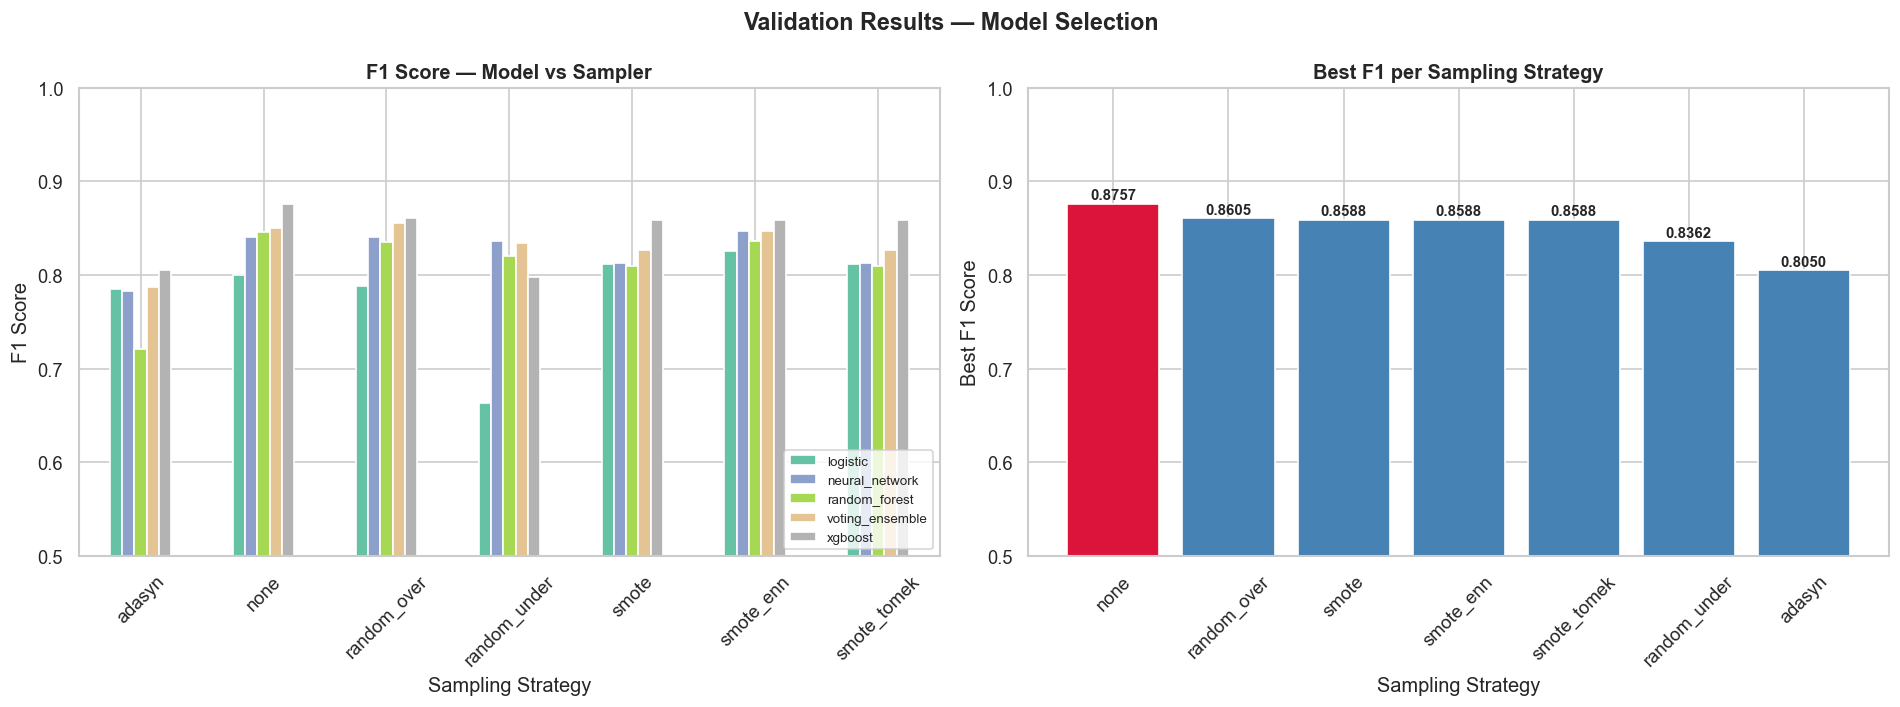

In [18]:
# ═══════════════════════════════════════════════════════════
# CELL 13 — Visualization
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: F1 per model per sampler
pivot_f1 = results_df.pivot(
    index="sampling", columns="model_name", values="f1"
)
pivot_f1.plot(kind="bar", ax=axes[0],
              colormap="Set2", edgecolor="white")
axes[0].set_title("F1 Score — Model vs Sampler",
                  fontweight="bold")
axes[0].set_xlabel("Sampling Strategy")
axes[0].set_ylabel("F1 Score")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(0.5, 1.0)

# Plot 2: Best F1 per sampler
best_per_sampler = results_df.groupby("sampling")["f1"].max().sort_values(ascending=False)
colors = ["crimson" if i == 0 else "steelblue"
          for i in range(len(best_per_sampler))]
axes[1].bar(best_per_sampler.index,
            best_per_sampler.values,
            color=colors, edgecolor="white")
axes[1].set_title("Best F1 per Sampling Strategy",
                  fontweight="bold")
axes[1].set_xlabel("Sampling Strategy")
axes[1].set_ylabel("Best F1 Score")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(0.5, 1.0)
for i, (name, val) in enumerate(best_per_sampler.items()):
    axes[1].text(i, val + 0.005, f"{val:.4f}",
                 ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Validation Results — Model Selection",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/validation_results.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# ═══════════════════════════════════════════════════════════
# CELL 14 — Best Model on Validation
# ═══════════════════════════════════════════════════════════
best_row = results_df.iloc[0]
best_key = f"{best_row['model_name']}_{best_row['sampling']}"

print(f"{'='*55}")
print(f"  BEST MODEL ON VALIDATION")
print(f"{'='*55}")
print(f"  Model     : {best_row['model_name']}")
print(f"  Sampling  : {best_row['sampling']}")
print(f"  F1-Score  : {best_row['f1']:.4f}  ← Primary Metric")
print(f"  PR-AUC    : {best_row['pr_auc']:.4f}")
print(f"  ROC-AUC   : {best_row['roc_auc']:.4f}")
print(f"  Threshold : {best_row['threshold']:.4f}")
print(f"  Features  : {best_row['n_features']}")
print(f"{'='*55}")

  BEST MODEL ON VALIDATION
  Model     : xgboost
  Sampling  : none
  F1-Score  : 0.8757  ← Primary Metric
  PR-AUC    : 0.8527
  ROC-AUC   : 0.9869
  Threshold : 0.4180
  Features  : 16


  FINAL TEST EVALUATION
  Model     : xgboost
  Sampling  : none
  Threshold : 0.4180
  F1-Score  : 0.8646  ← Primary Metric
  PR-AUC    : 0.8620
  ROC-AUC   : 0.9736

  Confusion Matrix:
  TN=56,851  FP=12
  FN=14  TP=83

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.87      0.86      0.86        97

    accuracy                           1.00     56960
   macro avg       0.94      0.93      0.93     56960
weighted avg       1.00      1.00      1.00     56960



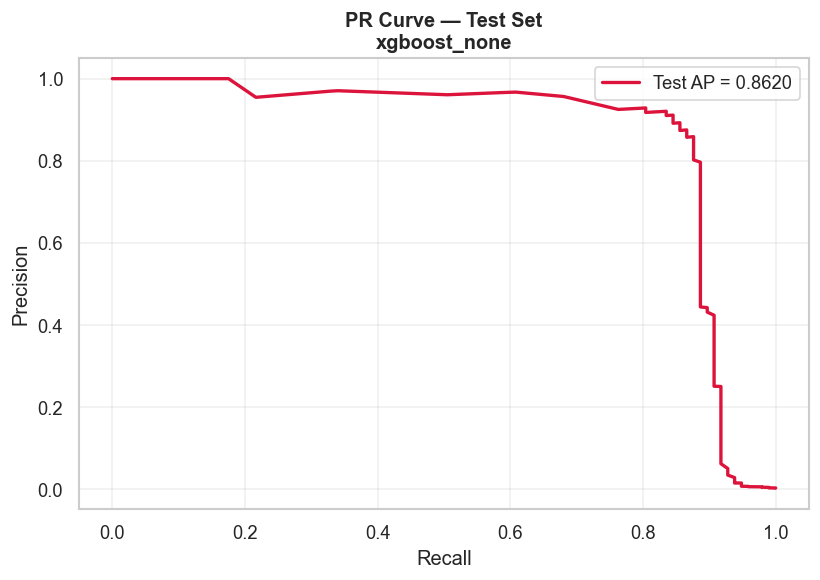


  VALIDATION vs TEST COMPARISON
  Metric    | Validation | Test
  F1-Score  | 0.8757     | 0.8646
  PR-AUC    | 0.8527     | 0.8620
  ROC-AUC   | 0.9869     | 0.9736


In [20]:
# ═══════════════════════════════════════════════════════════
# CELL 15 — Final Test Evaluation
# هنا بس بنشوف الأداء الحقيقي — مرة واحدة فقط
# مش بنختار حاجة أو بنعدل حاجة بناءً على التيست
# ═══════════════════════════════════════════════════════════

# Load Test
test_df     = pd.read_csv("../data/raw/test.csv")
X_test_raw  = test_df.drop(columns=["Class"])
y_test      = test_df["Class"].values

# Apply same feature engineering — بنفس الـ time_max من Train
X_test_eng    = apply_feature_engineering(X_test_raw, time_max=time_max)

# Apply same scaler — transform فقط مش fit
X_test_scaled = scaler.transform(X_test_eng)

# Apply best model's selector
best_payload  = trained_models[best_key]
best_model    = best_payload["model"]
best_selector = best_payload["selector"]
best_thresh   = best_payload["threshold"]

X_test_sel = best_selector.transform(X_test_scaled)

# Predict on Test
test_probs = best_model.predict_proba(X_test_sel)[:, 1]
test_preds = (test_probs >= best_thresh).astype(int)

# Metrics
test_f1      = f1_score(y_test, test_preds, zero_division=0)
test_pr_auc  = average_precision_score(y_test, test_probs)
test_roc_auc = roc_auc_score(y_test, test_probs)
test_cm      = confusion_matrix(y_test, test_preds)

print(f"{'='*55}")
print(f"  FINAL TEST EVALUATION")
print(f"  Model     : {best_row['model_name']}")
print(f"  Sampling  : {best_row['sampling']}")
print(f"{'='*55}")
print(f"  Threshold : {best_thresh:.4f}")
print(f"  F1-Score  : {test_f1:.4f}  ← Primary Metric")
print(f"  PR-AUC    : {test_pr_auc:.4f}")
print(f"  ROC-AUC   : {test_roc_auc:.4f}")
print(f"\n  Confusion Matrix:")
print(f"  TN={test_cm[0,0]:,}  FP={test_cm[0,1]:,}")
print(f"  FN={test_cm[1,0]:,}  TP={test_cm[1,1]:,}")
print(f"\n{classification_report(y_test, test_preds, zero_division=0)}")

# PR Curve on Test
precisions, recalls, _ = precision_recall_curve(y_test, test_probs)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls, precisions, lw=2, color="crimson",
        label=f"Test AP = {test_pr_auc:.4f}")
ax.set_title(f"PR Curve — Test Set\n{best_key}",
             fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/pr_curve_test.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Comparison: Validation vs Test
print(f"\n{'='*55}")
print(f"  VALIDATION vs TEST COMPARISON")
print(f"{'='*55}")
print(f"  Metric    | Validation | Test")
print(f"  F1-Score  | {best_row['f1']:.4f}     | {test_f1:.4f}")
print(f"  PR-AUC    | {best_row['pr_auc']:.4f}     | {test_pr_auc:.4f}")
print(f"  ROC-AUC   | {best_row['roc_auc']:.4f}     | {test_roc_auc:.4f}")